In [ ]:
# ============================================
# SECTION 1: DEPENDENCIES INSTALLATION
# ============================================
!pip install torch torchvision timm albumentations torchaudio -q

import os
!mkdir -p ~/.kaggle
!mv /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json  # Set permissions
!pip install -q kaggle

!kaggle datasets download -d karaagroaiprojects/cadi-ai -p /content/Data --unzip
!ls -R /content/Data | head -n 50


Dataset URL: https://www.kaggle.com/datasets/karaagroaiprojects/cadi-ai
License(s): GNU Affero General Public License 3.0
/content/Data:
Data

/content/Data/Data:
test
train
val

/content/Data/Data/test:
test

/content/Data/Data/test/test:
images
labels

/content/Data/Data/test/test/images:
1004.jpg
1026.jpg
1040.jpg
1045.jpg
1048.jpg
1093.jpg
1125.jpg
1133.jpg
1153.jpg
1189.jpg
1206.jpg
1226.jpg
1231.jpg
1306.jpg
1315.jpg
1346.jpg
1347.jpg
1349.jpg
1351.jpg
1354.jpg
1375.jpg
1404.jpg
1416.jpg
1454.jpg
1474.jpg
1475.jpg
1479.jpg
1495.jpg
14.jpg
1506.jpg
1517.jpg
1535.jpg
1541.jpg
1542.jpg


In [ ]:
# ============================================
# SECTION 2: DATASET DOWNLOAD AND PREPARATION
# ============================================


# Import required libraries
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
import time

# Define paths and classes
dataset_path = "/content/Data/Data"
train_path = os.path.join(dataset_path, "train/train")
val_path = os.path.join(dataset_path, "val/val")
test_path = os.path.join(dataset_path, "test/test")
classes = ['abiotic', 'insect', 'disease']

# Verify dataset structure
print("Train Folder Exists:", os.path.exists(train_path))
print("Validation Folder Exists:", os.path.exists(val_path))
print("Test Folder Exists:", os.path.exists(test_path))
print("Number of Training Images:", len(os.listdir(os.path.join(train_path, "images"))))
print("Number of Validation Images:", len(os.listdir(os.path.join(val_path, "images"))))
print("Number of Test Images:", len(os.listdir(os.path.join(test_path, "images"))))


Train Folder Exists: True
Validation Folder Exists: True
Test Folder Exists: True
Number of Training Images: 3788
Number of Validation Images: 710
Number of Test Images: 238


In [ ]:
# ============================================
# SECTION 3: CUSTOM DATASET CLASS
# ============================================
class CropDiseaseDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform

        # Filter only image files
        self.image_filenames = sorted([
            f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        # Load Image
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.images_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

        # Load Label
        label_path = os.path.join(self.labels_dir, img_name.replace(".jpg", ".txt"))
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                first_line = f.readline().strip()  # Read only first line

            label = int(first_line.split()[0]) if first_line else -1  # Get class label
        else:
            label = -1  # If label file is missing

        # Apply Transformations
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented["image"]

        return image, torch.tensor(label, dtype=torch.long)

# Define transformations
transform = A.Compose([
    A.RandomResizedCrop((224, 224), scale=(0.8, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Setup dataset paths
train_images = os.path.join(train_path, "images")
train_labels = os.path.join(train_path, "labels")
val_images = os.path.join(val_path, "images")
val_labels = os.path.join(val_path, "labels")
test_images = os.path.join(test_path, "images")
test_labels = os.path.join(test_path, "labels")

# Create dataset objects
train_dataset = CropDiseaseDataset(train_images, train_labels, transform=transform)
val_dataset = CropDiseaseDataset(val_images, val_labels, transform=transform)
test_dataset = CropDiseaseDataset(test_images, test_labels, transform=transform)

# DataLoader configuration
num_workers = min(4, torch.get_num_threads())
batch_size = 32 if torch.cuda.is_available() else 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                         num_workers=num_workers, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                       num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
print(f"🔹 Batch Size: {batch_size} | Num Workers: {num_workers}")


🔹 Batch Size: 32 | Num Workers: 1


In [ ]:
# =============================================================================
# SECTION 3: DATASET ORGANIZATION (SORTING INTO CLASS FOLDERS)
# =============================================================================

# Function to organize dataset images into class folders
def organize_dataset(dataset_type, input_path, output_path):
    """Organizes dataset images into class folders based on labels."""
    images_path = os.path.join(input_path, "images")
    labels_path = os.path.join(input_path, "labels")

    # Create output directory structure
    os.makedirs(output_path, exist_ok=True)
    for cls in classes:
        os.makedirs(os.path.join(output_path, cls), exist_ok=True)

    # Check if directories exist
    if not os.path.exists(labels_path) or not os.path.exists(images_path):
        print(f"⚠️ Skipping {dataset_type} - Missing directories!")
        return False

    # Process each label file
    for label_file in os.listdir(labels_path):
        if not label_file.endswith(".txt"):
            continue

        label_file_path = os.path.join(labels_path, label_file)

        # Read label file
        with open(label_file_path, "r") as f:
            lines = f.readlines()

        # Skip empty label files
        if not lines:
            continue

        # Extract class label
        class_idx = int(lines[0].split()[0])

        if class_idx >= len(classes):
            print(f"⚠️ Warning: Class index {class_idx} out of range in {label_file}")
            continue

        class_name = classes[class_idx]

        # Handle multiple image extensions
        img_name = label_file.replace(".txt", "")
        possible_extensions = [".jpg", ".jpeg", ".png"]

        for ext in possible_extensions:
            img_path = os.path.join(images_path, img_name + ext)
            if os.path.exists(img_path):
                import shutil
                shutil.move(img_path, os.path.join(output_path, class_name, img_name + ext))
                break

    return True

# Define sorted dataset paths
train_sorted_path = os.path.join(dataset_path, "train/train_sorted")
val_sorted_path = os.path.join(dataset_path, "val/val_sorted")
test_sorted_path = os.path.join(dataset_path, "test/test_sorted")

# Organize datasets by class
organize_dataset("train", train_path, train_sorted_path)
organize_dataset("val", val_path, val_sorted_path)
organize_dataset("test", test_path, test_sorted_path)

print("✅ Images sorted into class folders successfully!")

# Define standard transform for ImageFolder datasets
img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load organized datasets using ImageFolder
train_dataset = torchvision.datasets.ImageFolder(root=train_sorted_path, transform=img_transform)
val_dataset = torchvision.datasets.ImageFolder(root=val_sorted_path, transform=img_transform)
test_dataset = torchvision.datasets.ImageFolder(root=test_sorted_path, transform=img_transform)

# Create optimized DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                         num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                       num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)

# Print dataset sizes
print(f"✅ Training Samples: {len(train_dataset)}")
print(f"✅ Validation Samples: {len(val_dataset)}")
print(f"✅ Test Samples: {len(test_dataset)}")
print(f"🔹 Batch Size: {batch_size} | Num Workers: {num_workers}")

✅ Images sorted into class folders successfully!
✅ Training Samples: 2721
✅ Validation Samples: 525
✅ Test Samples: 178
🔹 Batch Size: 32 | Num Workers: 1


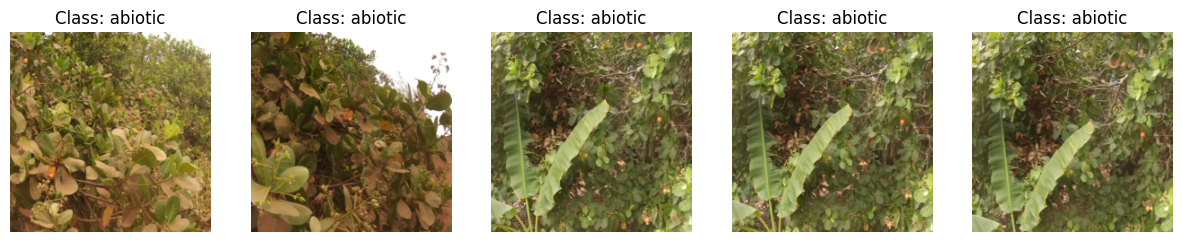

In [ ]:
# ============================================
# SECTION 4: DATA VISUALIZATION
# ============================================
# Function to Unnormalize Image
def unnormalize(image, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    mean = torch.tensor(mean).view(1, 1, 3)
    std = torch.tensor(std).view(1, 1, 3)
    return image * std + mean  # Reverse normalization

# Function to display images
def show_sample_images(dataset, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

    for i in range(num_samples):
        image, label = dataset[i]

        # Convert tensor to numpy & Unnormalize
        image = unnormalize(image.permute(1, 2, 0)).cpu().numpy()
        image = (image * 255).astype("uint8")  # Convert to 0-255 range

        # Display Image
        axes[i].imshow(image)
        title = f"Class: {classes[label]}" if label >= 0 else "Unknown"
        axes[i].set_title(title)
        axes[i].axis("off")

    plt.show()

# Display samples from the training dataset
show_sample_images(train_dataset)


In [ ]:
# ============================================
# SECTION 5: DATASET ORGANIZATION
# ============================================
# Organize datasets by class
def organize_dataset(dataset_type, input_path, output_path):
    """Organizes dataset images into class folders based on labels."""
    images_path = os.path.join(input_path, "images")
    labels_path = os.path.join(input_path, "labels")

    # Create output directory structure
    os.makedirs(output_path, exist_ok=True)
    for cls in classes:
        os.makedirs(os.path.join(output_path, cls), exist_ok=True)

    # Check if directories exist
    if not os.path.exists(labels_path) or not os.path.exists(images_path):
        print(f"⚠️ Skipping {dataset_type} - Missing directories!")
        return False

    # Process each label file
    for label_file in os.listdir(labels_path):
        if not label_file.endswith(".txt"):
            continue

        label_file_path = os.path.join(labels_path, label_file)

        # Read label file
        with open(label_file_path, "r") as f:
            lines = f.readlines()

        # Skip empty label files
        if not lines:
            continue

        # Extract class label
        class_idx = int(lines[0].split()[0])

        if class_idx >= len(classes):
            print(f"⚠️ Warning: Class index {class_idx} out of range in {label_file}")
            continue

        class_name = classes[class_idx]

        # Handle multiple image extensions
        img_name = label_file.replace(".txt", "")
        possible_extensions = [".jpg", ".jpeg", ".png"]

        for ext in possible_extensions:
            img_path = os.path.join(images_path, img_name + ext)
            if os.path.exists(img_path):
                import shutil
                shutil.move(img_path, os.path.join(output_path, class_name, img_name + ext))
                break

    return True

# Organize datasets into class folders
train_sorted_path = os.path.join(dataset_path, "train/train_sorted")
val_sorted_path = os.path.join(dataset_path, "val/val_sorted")
test_sorted_path = os.path.join(dataset_path, "test/test_sorted")

organize_dataset("train", train_path, train_sorted_path)
organize_dataset("val", val_path, val_sorted_path)
organize_dataset("test", test_path, test_sorted_path)

print("✅ Images sorted into class folders successfully!")

# Setup ImageFolder datasets with standardized transformation
img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets using ImageFolder (after organization)
train_dataset = torchvision.datasets.ImageFolder(root=train_sorted_path, transform=img_transform)
val_dataset = torchvision.datasets.ImageFolder(root=val_sorted_path, transform=img_transform)
test_dataset = torchvision.datasets.ImageFolder(root=test_sorted_path, transform=img_transform)

# Create DataLoaders for organized data
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

# Print dataset statistics
print(f"✅ Training Samples: {len(train_dataset)}")
print(f"✅ Validation Samples: {len(val_dataset)}")
print(f"✅ Test Samples: {len(test_dataset)}")
print(f"🔹 Batch Size: {batch_size} | Num Workers: {num_workers}")


✅ Images sorted into class folders successfully!
✅ Training Samples: 2721
✅ Validation Samples: 525
✅ Test Samples: 178
🔹 Batch Size: 32 | Num Workers: 1


In [ ]:
# ============================================
# SECTION 6: MODEL ARCHITECTURE
# ============================================
# Define model components
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class ShuffleBlock(nn.Module):
    def __init__(self, groups=2):
        super(ShuffleBlock, self).__init__()
        self.groups = groups

    def forward(self, x):
        batch_size, channels, height, width = x.size()
        channels_per_group = channels // self.groups
        x = x.view(batch_size, self.groups, channels_per_group, height, width)
        x = x.permute(0, 2, 1, 3, 4).contiguous()
        return x.view(batch_size, channels, height, width)

class GhostModule(nn.Module):
    def __init__(self, inp, oup, kernel_size=1, ratio=2, dw_size=3, stride=1):
        super(GhostModule, self).__init__()
        init_channels = oup // ratio
        new_channels = init_channels * (ratio - 1)

        self.primary_conv = nn.Sequential(
            nn.Conv2d(inp, init_channels, kernel_size, stride, kernel_size//2, bias=False),
            nn.BatchNorm2d(init_channels),
            Swish()
        )

        self.cheap_operation = nn.Sequential(
            nn.Conv2d(init_channels, new_channels, dw_size, 1, dw_size//2, groups=init_channels, bias=False),
            nn.BatchNorm2d(new_channels),
            Swish()
        )

    def forward(self, x):
        primary = self.primary_conv(x)
        cheap = self.cheap_operation(primary)
        return torch.cat([primary, cheap], dim=1)

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, kernel_size//2, groups=in_channels, bias=False)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, 1, 0, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.swish = Swish()

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return self.swish(x)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            Swish(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class FusionNet(nn.Module):
    def __init__(self, num_classes=3):
        super(FusionNet, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.swish = Swish()

        # Block 1
        self.ghost1 = GhostModule(32, 64)
        self.dwconv1 = DepthwiseSeparableConv(64, 128)
        self.se1 = SEBlock(128)

        # Block 2
        self.shuffle1 = ShuffleBlock()
        self.ghost2 = GhostModule(128, 256)
        self.dwconv2 = DepthwiseSeparableConv(256, 512)
        self.se2 = SEBlock(512)

        # Block 3
        self.shuffle2 = ShuffleBlock()
        self.ghost3 = GhostModule(512, 768)
        self.dwconv3 = DepthwiseSeparableConv(768, 1024)
        self.se3 = SEBlock(1024)

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.swish(self.bn1(self.conv1(x)))

        x = self.ghost1(x)
        x = self.dwconv1(x)
        x = self.se1(x)

        x = self.shuffle1(x)
        x = self.ghost2(x)
        x = self.dwconv2(x)
        x = self.se2(x)

        x = self.shuffle2(x)
        x = self.ghost3(x)
        x = self.dwconv3(x)
        x = self.se3(x)

        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FusionNet(num_classes=3).to(device)
print("✅ Using Device:", device)
print(model)

✅ Using Device: cuda
FusionNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (swish): Swish()
  (ghost1): GhostModule(
    (primary_conv): Sequential(
      (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): Swish()
    )
    (cheap_operation): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): Swish()
    )
  )
  (dwconv1): DepthwiseSeparableConv(
    (depthwise): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
    (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(128, eps=1e-05, momentum=0

In [ ]:
# ============================================
# SECTION 7: TRAINING SETUP
# ============================================
# Define training and validation functions
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
scaler = GradScaler()

def train_model(model, train_loader, criterion, optimizer, device, scaler=None, clip_value=1.0):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        # Mixed Precision if scaler available
        if scaler:
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_value)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_value)
            optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        # Clean up memory
        del loss
        torch.cuda.empty_cache()

    return total_loss / len(train_loader), 100 * correct / total

def validate_model(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    return val_loss, val_accuracy

<ipython-input-11-47982422fd6b>:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
# ============================================
# SECTION 8: TRAINING LOOP
# ============================================
# Training parameters
num_epochs = 35
best_val_loss = float("inf")
patience = 5
no_improve_epochs = 0

# Lists to store metrics
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# Training loop
for epoch in range(num_epochs):
    start_time = time.perf_counter()

    # Train and validate
    train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device, scaler)
    val_loss, val_acc = validate_model(model, val_loader, criterion, device)

    # Store metrics for plotting
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Update scheduler
    scheduler.step(val_loss)

    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve_epochs = 0
        torch.save(model.state_dict(), "best_fusionnet.pth")
        print("✅ Model improved & saved!")
    else:
        no_improve_epochs += 1

    # Early stopping
    if no_improve_epochs >= patience:
        print(f"⏹ Early stopping triggered! No improvement for {patience} epochs.")
        break

    # Calculate epoch time
    epoch_time = time.perf_counter() - start_time

    # Print metrics
    current_lr = optimizer.param_groups[0]['lr']
    print(f"📢 Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% - "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% - "
          f"LR: {current_lr:.6f} - Time: {epoch_time:.2f}s")

<ipython-input-11-47982422fd6b>:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
<ipython-input-11-47982422fd6b>:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


✅ Model improved & saved!
📢 Epoch [1/35] - Train Loss: 0.9601, Train Acc: 54.87% - Val Loss: 0.8956, Val Acc: 59.81% - LR: 0.001000 - Time: 225.49s
📢 Epoch [2/35] - Train Loss: 0.9048, Train Acc: 57.77% - Val Loss: 0.9951, Val Acc: 52.57% - LR: 0.001000 - Time: 233.73s
✅ Model improved & saved!
📢 Epoch [3/35] - Train Loss: 0.8863, Train Acc: 57.96% - Val Loss: 0.8183, Val Acc: 63.24% - LR: 0.001000 - Time: 227.58s
📢 Epoch [4/35] - Train Loss: 0.8594, Train Acc: 59.39% - Val Loss: 0.8607, Val Acc: 60.00% - LR: 0.001000 - Time: 234.96s
📢 Epoch [5/35] - Train Loss: 0.8574, Train Acc: 60.64% - Val Loss: 1.4730, Val Acc: 52.38% - LR: 0.001000 - Time: 227.82s
📢 Epoch [6/35] - Train Loss: 0.8477, Train Acc: 61.48% - Val Loss: 0.8435, Val Acc: 60.76% - LR: 0.001000 - Time: 226.42s
📢 Epoch [7/35] - Train Loss: 0.8009, Train Acc: 63.18% - Val Loss: 1.3664, Val Acc: 44.76% - LR: 0.000500 - Time: 230.37s
✅ Model improved & saved!
📢 Epoch [8/35] - Train Loss: 0.7512, Train Acc: 66.23% - Val Loss: 0

Evaluating model on test set...


<ipython-input-13-4b0371ce67cf>:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluating model on validation set...


<ipython-input-13-4b0371ce67cf>:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Evaluating model on training set...


<ipython-input-13-4b0371ce67cf>:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



========== EVALUATION RESULTS ==========
TRAINING SET:
  Loss: 0.3726
  Accuracy: 84.53%
  Top-5 Accuracy: 100.00%
  Precision (macro): 0.8862
  Recall (macro): 0.7949
  F1 Score (macro): 0.8174

VALIDATION SET:
  Loss: 0.6572
  Accuracy: 73.90%
  Top-5 Accuracy: 100.00%
  Precision (macro): 0.7925
  Recall (macro): 0.6696
  F1 Score (macro): 0.6946

TEST SET:
  Loss: 0.9469
  Accuracy: 67.42%
  Top-5 Accuracy: 100.00%
  Precision (macro): 0.7229
  Recall (macro): 0.6070
  F1 Score (macro): 0.6258
  ROC AUC (micro): 0.8374


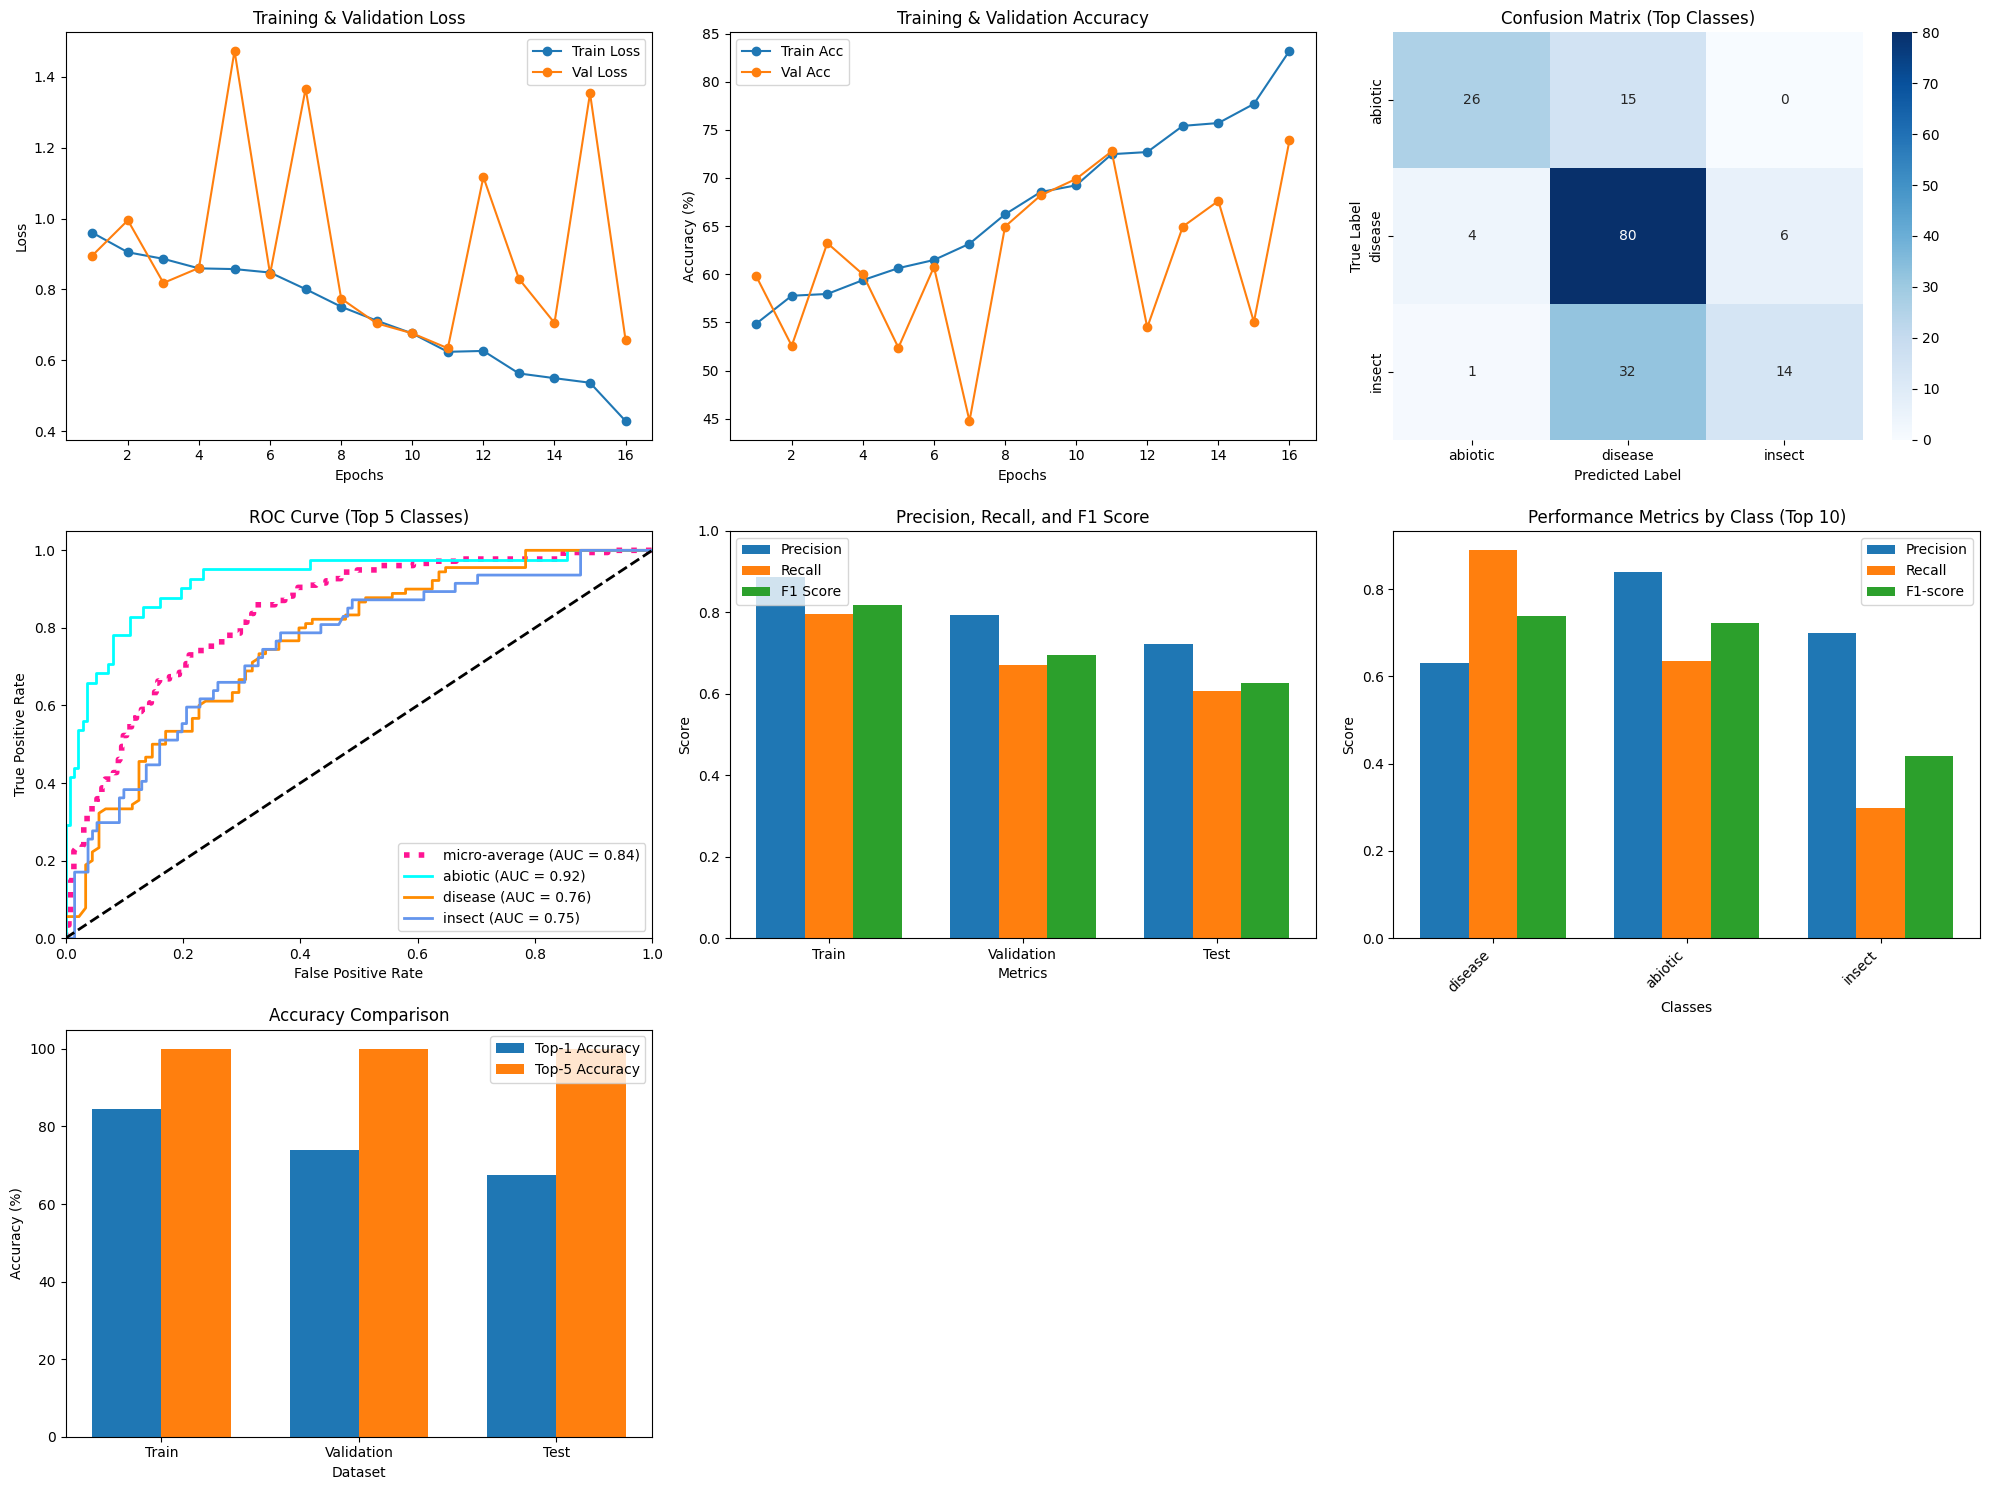

In [ ]:
# ============================================
# SECTION 9: EVALUATION AND VISUALIZATION
# ============================================
# Import additional libraries for metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_fscore_support
import numpy as np
import seaborn as sns

# Function for comprehensive model evaluation
def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.inference_mode():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            # Get predictions and probabilities
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            # Store for metrics calculation
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            total_loss += loss.item()

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Calculate metrics
    accuracy = 100 * np.mean(all_preds == all_labels)

    # Precision, recall, F1 (macro average)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro'
    )

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Classification report
    cr = classification_report(
        all_labels, all_preds,
        target_names=data_loader.dataset.classes,
        output_dict=True
    )

    # Top-5 accuracy
    top5_correct = 0
    for i, label in enumerate(all_labels):
        top5_indices = np.argsort(all_probs[i])[-5:]
        if label in top5_indices:
            top5_correct += 1
    top5_accuracy = 100 * top5_correct / len(all_labels)

    # ROC AUC for multiclass (one-vs-rest)
    n_classes = len(data_loader.dataset.classes)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(
            (all_labels == i).astype(int),
            all_probs[:, i]
        )
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(
        np.eye(n_classes)[all_labels].ravel(),
        all_probs.ravel()
    )
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    return {
        'loss': total_loss / len(data_loader),
        'accuracy': accuracy,
        'top5_accuracy': top5_accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'classification_report': cr,
        'roc_auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'predictions': all_preds,
        'true_labels': all_labels,
        'probabilities': all_probs
    }

# Evaluate on test set
print("Evaluating model on test set...")
test_results = evaluate_model(model, test_loader, criterion, device)

# Evaluate on validation set
print("Evaluating model on validation set...")
val_results = evaluate_model(model, val_loader, criterion, device)

# Evaluate on training set
print("Evaluating model on training set...")
train_results = evaluate_model(model, train_loader, criterion, device)

# Print comprehensive results
print("\n========== EVALUATION RESULTS ==========")
print(f"TRAINING SET:")
print(f"  Loss: {train_results['loss']:.4f}")
print(f"  Accuracy: {train_results['accuracy']:.2f}%")
print(f"  Top-5 Accuracy: {train_results['top5_accuracy']:.2f}%")
print(f"  Precision (macro): {train_results['precision']:.4f}")
print(f"  Recall (macro): {train_results['recall']:.4f}")
print(f"  F1 Score (macro): {train_results['f1']:.4f}")

print("\nVALIDATION SET:")
print(f"  Loss: {val_results['loss']:.4f}")
print(f"  Accuracy: {val_results['accuracy']:.2f}%")
print(f"  Top-5 Accuracy: {val_results['top5_accuracy']:.2f}%")
print(f"  Precision (macro): {val_results['precision']:.4f}")
print(f"  Recall (macro): {val_results['recall']:.4f}")
print(f"  F1 Score (macro): {val_results['f1']:.4f}")

print("\nTEST SET:")
print(f"  Loss: {test_results['loss']:.4f}")
print(f"  Accuracy: {test_results['accuracy']:.2f}%")
print(f"  Top-5 Accuracy: {test_results['top5_accuracy']:.2f}%")
print(f"  Precision (macro): {test_results['precision']:.4f}")
print(f"  Recall (macro): {test_results['recall']:.4f}")
print(f"  F1 Score (macro): {test_results['f1']:.4f}")
print(f"  ROC AUC (micro): {test_results['roc_auc']['micro']:.4f}")

# Create visualizations
plt.figure(figsize=(20, 15))

# 1. Plot Training & Validation Loss
plt.subplot(3, 3, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", marker="o")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Val Loss", marker="o")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

# 2. Plot Training & Validation Accuracy
plt.subplot(3, 3, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label="Train Acc", marker="o")
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label="Val Acc", marker="o")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training & Validation Accuracy")
plt.legend()

# 3. Plot Confusion Matrix for Test Set
plt.subplot(3, 3, 3)
cm = test_results['confusion_matrix']
# If many classes, show top 10 by frequency
if len(test_loader.dataset.classes) > 10:
    class_counts = np.sum(cm, axis=1)
    top_indices = np.argsort(class_counts)[-10:]
    cm_display = cm[top_indices][:, top_indices]
    class_names_display = [test_loader.dataset.classes[i] for i in top_indices]
else:
    cm_display = cm
    class_names_display = test_loader.dataset.classes

sns.heatmap(cm_display, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_display, yticklabels=class_names_display)
plt.title('Confusion Matrix (Top Classes)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# 4. Plot ROC Curve (for top 5 classes by AUC + micro-average)
plt.subplot(3, 3, 4)
roc_auc = test_results['roc_auc']
fpr = test_results['fpr']
tpr = test_results['tpr']

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=4)

# Plot ROC curves for top 5 classes by AUC
class_indices = sorted([(i, roc_auc[i]) for i in range(len(test_loader.dataset.classes))
                        if i in roc_auc and not np.isnan(roc_auc[i])],
                       key=lambda x: x[1], reverse=True)[:5]

colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red']
for i, (class_idx, auc_value) in enumerate(class_indices):
    plt.plot(fpr[class_idx], tpr[class_idx], color=colors[i], lw=2,
             label=f'{test_loader.dataset.classes[class_idx]} (AUC = {auc_value:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Top 5 Classes)')
plt.legend(loc="lower right")

# 5. Plot Precision-Recall-F1 Bar Chart
plt.subplot(3, 3, 5)
metrics_data = {
    'Precision': [train_results['precision'], val_results['precision'], test_results['precision']],
    'Recall': [train_results['recall'], val_results['recall'], test_results['recall']],
    'F1 Score': [train_results['f1'], val_results['f1'], test_results['f1']]
}

x = np.arange(len(metrics_data))
width = 0.25
multiplier = 0

for attribute, measurement in metrics_data.items():
    offset = width * multiplier
    rects = plt.bar(x + offset, measurement, width, label=attribute)
    multiplier += 1

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score')
plt.xticks(x + width, ['Train', 'Validation', 'Test'])
plt.legend(loc='upper left')
plt.ylim(0, 1)

# 6. Plot Classification Report (Top 10 Classes by F1 Score)
plt.subplot(3, 3, 6)
cr = test_results['classification_report']
# Extract class metrics (excluding averages)
class_metrics = {k: v for k, v in cr.items() if k not in ['accuracy', 'macro avg', 'weighted avg']}
# Sort by F1 score and take top 10
top_classes = sorted(class_metrics.items(), key=lambda x: x[1]['f1-score'], reverse=True)[:10]

class_names = [test_loader.dataset.classes[int(k)] if k.isdigit() else k for k, _ in top_classes]
class_f1 = [v['f1-score'] for _, v in top_classes]
class_precision = [v['precision'] for _, v in top_classes]
class_recall = [v['recall'] for _, v in top_classes]

x = np.arange(len(class_names))
width = 0.25

plt.bar(x - width, class_precision, width, label='Precision')
plt.bar(x, class_recall, width, label='Recall')
plt.bar(x + width, class_f1, width, label='F1-score')

plt.xlabel('Classes')
plt.ylabel('Score')
plt.title('Performance Metrics by Class (Top 10)')
plt.xticks(x, class_names, rotation=45, ha='right')
plt.legend()

# 7. Accuracy Comparison
plt.subplot(3, 3, 7)
datasets = ['Train', 'Validation', 'Test']
accuracies = [train_results['accuracy'], val_results['accuracy'], test_results['accuracy']]
top5_accuracies = [train_results['top5_accuracy'], val_results['top5_accuracy'], test_results['top5_accuracy']]

x = np.arange(len(datasets))
width = 0.35

plt.bar(x - width/2, accuracies, width, label='Top-1 Accuracy')
plt.bar(x + width/2, top5_accuracies, width, label='Top-5 Accuracy')

plt.xlabel('Dataset')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison')
plt.xticks(x, datasets)
plt.legend()

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=300, bbox_inches='tight')
plt.show()

